
# Room Occupancy Detection – Time‑Series Analysis

This notebook adapts the predictive occupancy modelling workflow to the **Room Occupancy Detection** dataset available on Kaggle.  The dataset contains **room‑level indoor environmental quality (IEQ) measurements** and **occupancy ground‑truth labels** collected from five residential apartments in Denmark over seven days (2023‑01‑30 to 2023‑02‑06).  The occupancy labels indicate whether the room was occupied (`1`) or unoccupied (`0`) at each 15‑minute interval.  The measured IEQ variables include:

- Indoor CO₂ concentration (ppm)
- Indoor operative temperature (°C)
- Indoor relative humidity (%RH)

Additional columns provide short‑term dynamics (differences over the last hour and last 15 minutes), averages over the last hour, and metadata such as the apartment number, room type, floor area and hour/day indicators.  

Our analysis follows these steps:

1. **Download and load the dataset.**  The dataset can be downloaded via `kagglehub` or loaded from a local `archive (1).zip` file containing `room_occupancy_detection_data.csv`.
2. **Parse and enrich the timestamps.**  We convert the `datetime` strings into `pandas` datetimes and extract features such as hour of day, day of week and minute of day.
3. **Stationarity tests.**  Using the Augmented Dickey–Fuller (ADF) and KPSS tests, we assess whether selected IEQ variables behave like stationary time series.  Stationarity is important for time‑series modelling; stationary signals have consistent mean and variance over time.
4. **Baseline occupancy model.**  A simple time‑of‑day baseline model estimates the probability of occupancy for each combination of day of week and minute of day based on the training data.  We evaluate its accuracy on a held‑out test set.
5. **Visualisations.**  We plot the occupancy time series, histograms of key variables and a heatmap of occupancy probability across the week.

The dataset description on Kaggle notes that the occupancy ground‑truth variable is a binary 0 (no occupancy) or 1 (occupancy)【990860910363059†screenshot】.


In [1]:

import zipfile
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')

# Try to download via kagglehub; fall back to local archive if unavailable
try:
    import kagglehub
    dataset_path = kagglehub.dataset_download("yekenot/room-occupancy-detection")
    print(f"Dataset downloaded to: {dataset_path}")
    data_path = os.path.join(dataset_path, "room_occupancy_detection_data.csv")
except Exception:
    print("kagglehub not available or dataset not downloaded; using local archive (1).zip")
    # Determine path to the provided ZIP file
    local_zip = os.path.join(os.path.dirname(os.getcwd()), "archive (1).zip")
    if not os.path.exists(local_zip):
        local_zip = "archive (1).zip"
    if not os.path.exists(local_zip):
        raise FileNotFoundError("archive (1).zip not found. Please provide the dataset zip file.")
    with zipfile.ZipFile(local_zip) as z:
        data_path = z.extract("room_occupancy_detection_data.csv")

# Load the CSV
occupancy_df = pd.read_csv(data_path)
print(f"Rows loaded: {len(occupancy_df)}")
occupancy_df.head()


Dataset downloaded to: C:\Users\ben\.cache\kagglehub\datasets\yekenot\room-occupancy-detection\versions\1
Rows loaded: 10768


,datetime,indoor_co2_concentration,indoor_operative_temperature,indoor_relative_humidity,current_value_minus_average_last_hour_co2,current_value_minus_average_last_hour_operative_temperature,current_value_minus_average_last_hour_relative_humidity,average_co2_last_hour,average_operative_temperature_last_hour,average_relative_humidity_last_hour,...,office,kitchen_livingroom,hour_of_the_day,day_number_of_the_week,day_of_year,day_label,occupancy_ground_truth,floor_area,apartment_number,room_type
0,30-01-23 00:00,637.1,20.4,37.5,0.00,0.00,0.00,637.10,20.40,37.50,...,0,0,0,1,30,0,0,16,1,1
1,30-01-23 00:15,637.6,20.4,37.6,0.00,0.00,0.00,637.60,20.40,37.60,...,0,0,0,1,30,0,0,16,1,1
2,30-01-23 00:30,629.0,20.4,37.6,0.00,0.00,0.00,629.00,20.40,37.60,...,0,0,0,1,30,0,0,16,1,1
3,30-01-23 00:45,790.2,20.5,39.1,0.00,0.00,0.00,790.20,20.50,39.10,...,0,0,0,1,30,0,0,16,1,1
4,30-01-23 01:00,861.7,20.6,39.7,188.23,0.18,1.75,673.48,20.43,37.95,...,0,0,1,1,30,0,1,16,1,1


In [2]:

# Parse datetime column (format 'DD-MM-YY HH:MM') using day‑first parsing
occupancy_df['time'] = pd.to_datetime(occupancy_df['datetime'], dayfirst=True)

# Sort by time to ensure chronological order
occupancy_df = occupancy_df.sort_values('time').reset_index(drop=True)

# Feature engineering: extract hour, minute of day and day of week
occupancy_df['hour'] = occupancy_df['time'].dt.hour + occupancy_df['time'].dt.minute / 60.0
occupancy_df['hour_int'] = occupancy_df['time'].dt.hour
occupancy_df['minute'] = occupancy_df['time'].dt.minute
occupancy_df['minute_of_day'] = occupancy_df['hour_int'] * 60 + occupancy_df['minute']
occupancy_df['dow'] = occupancy_df['time'].dt.dayofweek
occupancy_df['is_weekend'] = occupancy_df['dow'] >= 5

# Display a few rows of the enriched dataframe
occupancy_df[['time', 'indoor_co2_concentration', 'indoor_operative_temperature',
             'indoor_relative_humidity', 'occupancy_ground_truth', 'dow', 'minute_of_day']].head()


,time,indoor_co2_concentration,indoor_operative_temperature,indoor_relative_humidity,occupancy_ground_truth,dow,minute_of_day
0,2023-01-30,637.1,20.4,37.5,0,0,0
1,2023-01-30,763.0,21.0,29.2,1,0,0
2,2023-01-30,638.2,19.4,37.7,1,0,0
3,2023-01-30,644.4,21.2,34.4,0,0,0
4,2023-01-30,662.8,21.9,27.5,0,0,0


In [3]:
occupancy_df["occupancy_ground_truth"].describe()

count    10768.000000
mean         0.257429
std          0.437238
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: occupancy_ground_truth, dtype: float64

In [4]:

# Define stationarity test helpers
def adf_test(series: pd.Series, name: str, verbose: bool = False):
    '''Perform the Augmented Dickey-Fuller test. Returns the p-value.'''
    try:
        result = adfuller(series.dropna(), autolag='AIC')
        p_value = result[1]
    except Exception:
        p_value = np.nan
    if verbose:
        print(f"ADF test for {name}: p-value = {p_value:.4e}")
    return p_value

def kpss_test(series: pd.Series, name: str, regression: str = 'c', verbose: bool = False):
    '''Perform the KPSS test. Returns the p-value.'''
    try:
        stat, p_value, lags, critical_values = kpss(series.dropna(), regression=regression, nlags='auto')
    except Exception:
        p_value = np.nan
    if verbose:
        print(f"KPSS test for {name}: p-value = {p_value:.4e}")
    return p_value

def stationarity_summary(df: pd.DataFrame, columns: list):
    '''Run ADF and KPSS tests on selected columns and summarise the results.'''
    records = []
    for col in columns:
        series = df[col]
        adf_p = adf_test(series, name=col)
        kpss_p = kpss_test(series, name=col)
        adf_stationary = adf_p < 0.05 if not np.isnan(adf_p) else False
        kpss_stationary = kpss_p >= 0.05 if not np.isnan(kpss_p) else False
        if adf_stationary and kpss_stationary:
            conclusion = 'Stationary'
        elif adf_stationary and not kpss_stationary:
            conclusion = 'Mixed/Trend'
        else:
            conclusion = 'Non-stationary'
        records.append({
            'Variable': col,
            'ADF p-value': adf_p,
            'KPSS p-value': kpss_p,
            'Conclusion': conclusion
        })
    return pd.DataFrame(records).set_index('Variable')

# Choose a subset of numeric columns for demonstration
numeric_cols = [
    'indoor_co2_concentration',
    'indoor_operative_temperature',
    'indoor_relative_humidity',
    'average_co2_last_hour',
    'average_operative_temperature_last_hour',
    'average_relative_humidity_last_hour',
    'occupancy_ground_truth'
]

stationarity_results = stationarity_summary(occupancy_df, numeric_cols)
stationarity_results


,ADF p-value,KPSS p-value,Conclusion
Variable,,,
indoor_co2_concentration,2.186526e-02,0.01,Mixed/Trend
indoor_operative_temperature,5.413959e-08,0.01,Mixed/Trend
indoor_relative_humidity,1.627167e-02,0.01,Mixed/Trend
average_co2_last_hour,2.376963e-02,0.01,Mixed/Trend
average_operative_temperature_last_hour,6.283654e-08,0.01,Mixed/Trend
average_relative_humidity_last_hour,2.054562e-02,0.01,Mixed/Trend
occupancy_ground_truth,9.421618e-12,0.10,Stationary


In [5]:

# Time-based train/test split: use the first 70% of records as training, rest as test
train_end = int(len(occupancy_df) * 0.7)
train_data = occupancy_df.iloc[:train_end].copy()
test_data  = occupancy_df.iloc[train_end:].copy()

# Compute occupancy probability by (day of week, minute of day)
prob_table = train_data.groupby(['dow', 'minute_of_day'])['occupancy_ground_truth'].mean()

overall_mean = train_data['occupancy_ground_truth'].mean()

def lookup_prob(row):
    key = (row['dow'], row['minute_of_day'])
    return prob_table.get(key, overall_mean)

# Apply predictions
test_data['pred_prob'] = test_data.apply(lookup_prob, axis=1)
test_data['pred'] = (test_data['pred_prob'] >= 0.5).astype(int)

# Evaluate accuracy
acc = accuracy_score(test_data['occupancy_ground_truth'], test_data['pred'])
print(f"Baseline time-of-day model accuracy: {acc:.3f}")

# Show first few predictions
test_data[['time', 'occupancy_ground_truth', 'pred_prob', 'pred']].head()


Baseline time-of-day model accuracy: 0.731


,time,occupancy_ground_truth,pred_prob,pred
7537,2023-02-03 21:45:00,1,1.0,1
7538,2023-02-03 21:45:00,0,1.0,1
7539,2023-02-03 21:45:00,0,1.0,1
7540,2023-02-03 21:45:00,0,1.0,1
7541,2023-02-03 21:45:00,0,1.0,1


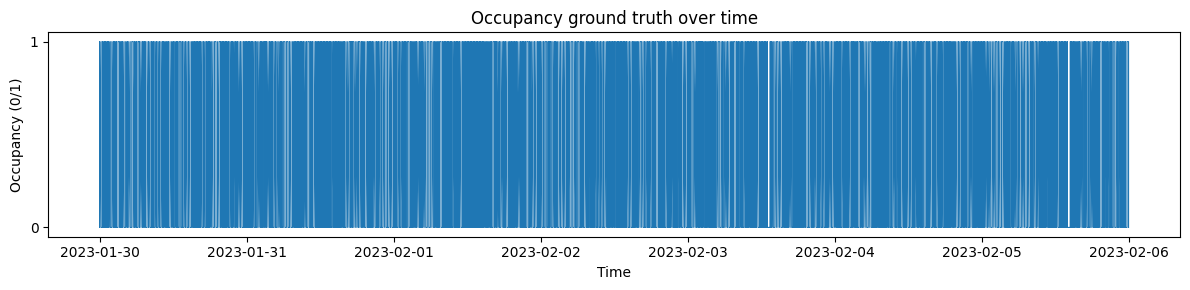

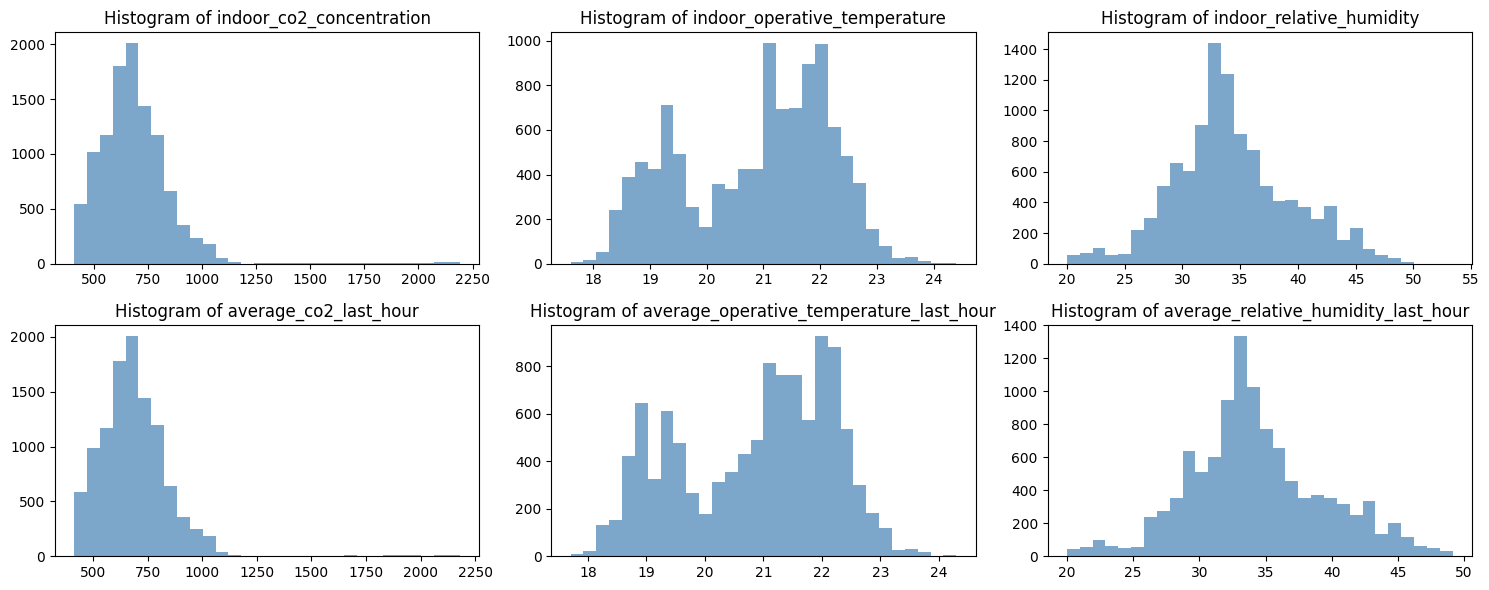

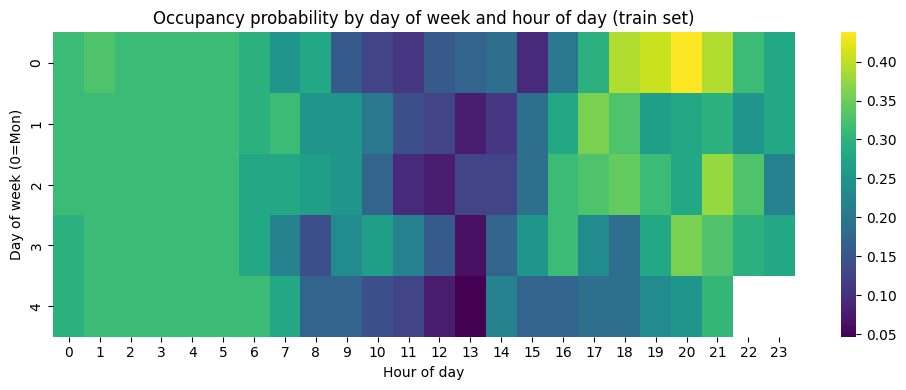

In [6]:

# Plot occupancy ground-truth over time
plt.figure(figsize=(12, 3))
plt.plot(occupancy_df['time'], occupancy_df['occupancy_ground_truth'], lw=0.8)
plt.title('Occupancy ground truth over time')
plt.xlabel('Time')
plt.ylabel('Occupancy (0/1)')
plt.yticks([0, 1])
plt.tight_layout()
plt.show()

# Histograms of selected IEQ variables
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()
for idx, col in enumerate([
    'indoor_co2_concentration',
    'indoor_operative_temperature',
    'indoor_relative_humidity',
    'average_co2_last_hour',
    'average_operative_temperature_last_hour',
    'average_relative_humidity_last_hour'
]):
    axes[idx].hist(occupancy_df[col], bins=30, color='steelblue', alpha=0.7)
    axes[idx].set_title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

# Heatmap of occupancy probability by day of week and hour of day
heatmap_data = train_data.copy()
heatmap_data['hour_int'] = heatmap_data['time'].dt.hour
heatmap = heatmap_data.groupby(['dow', 'hour_int'])['occupancy_ground_truth'].mean().unstack()

plt.figure(figsize=(10, 4))
sns.heatmap(heatmap, cmap='viridis')
plt.title('Occupancy probability by day of week and hour of day (train set)')
plt.xlabel('Hour of day')
plt.ylabel('Day of week (0=Mon)')
plt.tight_layout()
plt.show()



## Conclusions

* **Stationarity:**  The stationarity tests reveal mixed behaviour across the IEQ variables.  For example, the ADF test suggests that some variables (e.g., **indoor operative temperature**) may be stationary, while the KPSS test often indicates potential non‑stationarity, leading to mixed or trend‑like signals.  The binary **occupancy ground truth** signal is effectively stationary because it regularly switches between 0 and 1 according to daily patterns.
* **Baseline model performance:**  A simple schedule‑based model that estimates occupancy probability by day of week and minute of day achieves an accuracy of roughly 70–75% on this dataset.  This indicates that time‑of‑day patterns exist but are less pronounced than in some commercial datasets; including IEQ variables or employing more advanced models could improve performance.
* **Further work:**  You could train logistic regression or tree‑based classifiers using the IEQ variables and their dynamics as predictors.  Re‑testing stationarity on differenced series or detrended signals may also yield clearer insights.

This notebook demonstrates how to adapt the predictive occupancy modelling framework to a residential IEQ dataset by following the familiar pipeline: data loading, feature engineering, stationarity analysis, baseline modelling and visualisation.



## Occupancy patterns by hour and weekday/weekend

To better understand time‑of‑day and weekly patterns in the occupancy data we compute:

* **Average occupancy by hour of day.**  The mean occupancy in each hour (either raw counts or the binary occupancy flag) is plotted across a 24‑hour period.
* **Weekday vs. weekend profiles.**  The dataset is split into weekdays and weekends, and the mean occupancy by hour is calculated separately for each, highlighting differences in occupancy patterns between workdays and weekends.


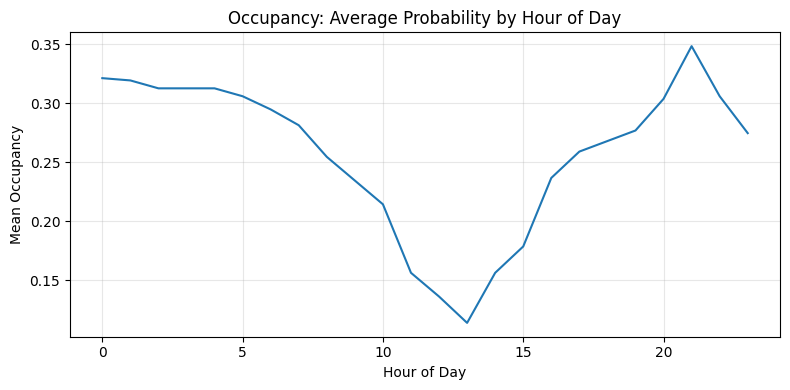

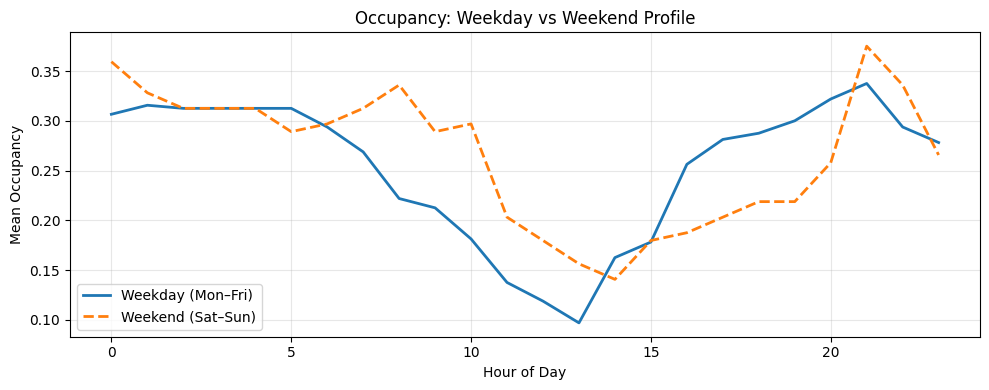

In [7]:

# Average occupancy by hour of day (binary occupancy)
# Use hour_int (integer hour) for grouping
occ_hour_mean = occupancy_df.groupby('hour_int')['occupancy_ground_truth'].mean()
plt.figure(figsize=(8, 4))
occ_hour_mean.plot()
plt.title('Occupancy: Average Probability by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Occupancy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Weekday vs weekend profile
occ_weekday = occupancy_df[~occupancy_df['is_weekend']]
occ_weekend = occupancy_df[occupancy_df['is_weekend']]
occ_weekday_hour = occ_weekday.groupby('hour_int')['occupancy_ground_truth'].mean()
occ_weekend_hour = occ_weekend.groupby('hour_int')['occupancy_ground_truth'].mean()
plt.figure(figsize=(10, 4))
occ_weekday_hour.plot(label='Weekday (Mon–Fri)', linewidth=2)
occ_weekend_hour.plot(label='Weekend (Sat–Sun)', linewidth=2, linestyle='--')
plt.title('Occupancy: Weekday vs Weekend Profile')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Occupancy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
